# Web Scraping

## Introduccion

El **web scraping** es una técnica utilizada para extraer información de páginas web, especialmente cuando los datos no están estructurados en formatos como archivos .csv o bases de datos.

Para acceder a una página web desde Python, es necesario realizar una solicitud (request) al servidor. Para esto, se utiliza la librería de Python: Requests. Esta librería permite enviar solicitudes a través del protocolo HTTP y obtener el contenido de una página.

Es importante saber que cada vez que ejecutamos el comando get estamos enviando una consulta al servidor. Hay que ser responsables en el uso de las consultas ya que si se ejecutan demasiadas pueden generar problemas en el servidor o incluso pueden bloquear nuestra IP por uso indebido.

In [5]:
!pip install bs4


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [6]:
import requests

url = "https://lcd.exactas.uba.ar/materias/"
r = requests.get(url)

### Status Code

Al hacer una solicitud se nos pueden devolver distintos tipos de códigos de estado. Si el código es del tipo 2** entonces está asociado a una solicitud exitosa. Si es de tipo 4** implica un error del cliente, por ejemplo, el famoso 404 que ocurre cuando intentamos acceder a un dominio inexistente. Por último, si el error es de tipo 5** implica un error en el servidor.

In [7]:
print(r.status_code)

200


In [8]:
url2 = "https://lcd.exactas.uba.ar/materiassss/"
print(requests.get(url2).status_code)

404


La respuesta que obtenemos del servidor es un string con todo el código HTML. Para poder utilizar este código de manera más sencilla es necesario usar un parser (es decir, un analizador semántico) que reconstruya la estructura del HTML y nos permita navegar más facilmente.

In [9]:
print(len(r.text))
r.text

122399


'<!DOCTYPE html>\n<html class="no-overflow-y avada-html-layout-wide avada-html-header-position-top avada-is-100-percent-template avada-header-color-not-opaque" lang="es-AR" prefix="og: http://ogp.me/ns# fb: http://ogp.me/ns/fb#">\n<head>\n\t<meta http-equiv="X-UA-Compatible" content="IE=edge" />\n\t<meta http-equiv="Content-Type" content="text/html; charset=utf-8"/>\n\t<meta name="viewport" content="width=device-width, initial-scale=1" />\n\t<title>Plan de estudios &#8211; Licenciatura en Datos &#8211; Exactas &#8211; UBA</title>\n\t\t<style>\r\n\t\t#wpadminbar #wp-admin-bar-cp_plugins_top_button .ab-icon:before {\r\n\t\t\tcontent: "\\f533";\r\n\t\t\ttop: 3px;\r\n\t\t}\r\n\t\t#wpadminbar #wp-admin-bar-cp_plugins_top_button .ab-icon {\r\n\t\t\ttransform: rotate(45deg);\r\n\t\t}\r\n\t\t</style>\r\n\t<style>\n#wpadminbar #wp-admin-bar-vtrts_free_top_button .ab-icon:before {\n\tcontent: "\\f185";\n\tcolor: #1DAE22;\n\ttop: 3px;\n}\n</style><meta name="dlm-version" content="4.8.2"><link rel

### Parsers

Para poder parsear el código vamos a usar la librería **BeautifulSoup** de Python. Junto a ella hay q elegir un *parser*. Se pueden usar varios como 'html.parser' o 'lxml'.

Pueden buscar mas información de la librería en la [documentación](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).

In [10]:
from bs4 import BeautifulSoup
materias = BeautifulSoup(r.text, 'html.parser')
materias

<!DOCTYPE html>

<html class="no-overflow-y avada-html-layout-wide avada-html-header-position-top avada-is-100-percent-template avada-header-color-not-opaque" lang="es-AR" prefix="og: http://ogp.me/ns# fb: http://ogp.me/ns/fb#">
<head>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<title>Plan de estudios – Licenciatura en Datos – Exactas – UBA</title>
<style>
		#wpadminbar #wp-admin-bar-cp_plugins_top_button .ab-icon:before {
			content: "\f533";
			top: 3px;
		}
		#wpadminbar #wp-admin-bar-cp_plugins_top_button .ab-icon {
			transform: rotate(45deg);
		}
		</style>
<style>
#wpadminbar #wp-admin-bar-vtrts_free_top_button .ab-icon:before {
	content: "\f185";
	color: #1DAE22;
	top: 3px;
}
</style><meta content="4.8.2" name="dlm-version"/><link href="//s.w.org" rel="dns-prefetch"/>
<link href="https://lcd.exactas.uba.ar/feed/" rel="alternate" 

## Estructura HTML

Un elemento de HTML es la estructura más básica de HTML. Estos contienen una **etiqueta** (tag) que le define ciertas propiedades. Algunas etiquetas comunes son:

*   \<p>: para escribir texto en formato de parrafos
*   \<h1>, \<h2>, \<h3>: usado para titulos y subtitulos
*   \<a>: para hipervínculos
*   \<img>: para insertar imagenes
*   \<ol>, \<ul>, \<li>: para definir listar ordenadas (ordered list), listas no ordenadas (unordered list) y elementos de las listas respectivamente

Cada elemento a su vez, admite atributos. Uno muy común es la *clase* que permite agrupar elementos dentro de un mismo tipo para podes darles un formato visual similar. Otros pueden ser *width*, *height* o *src*.

Además, cada elemento puede tener elementos dentro, obteniendo así una estructura arbolada.

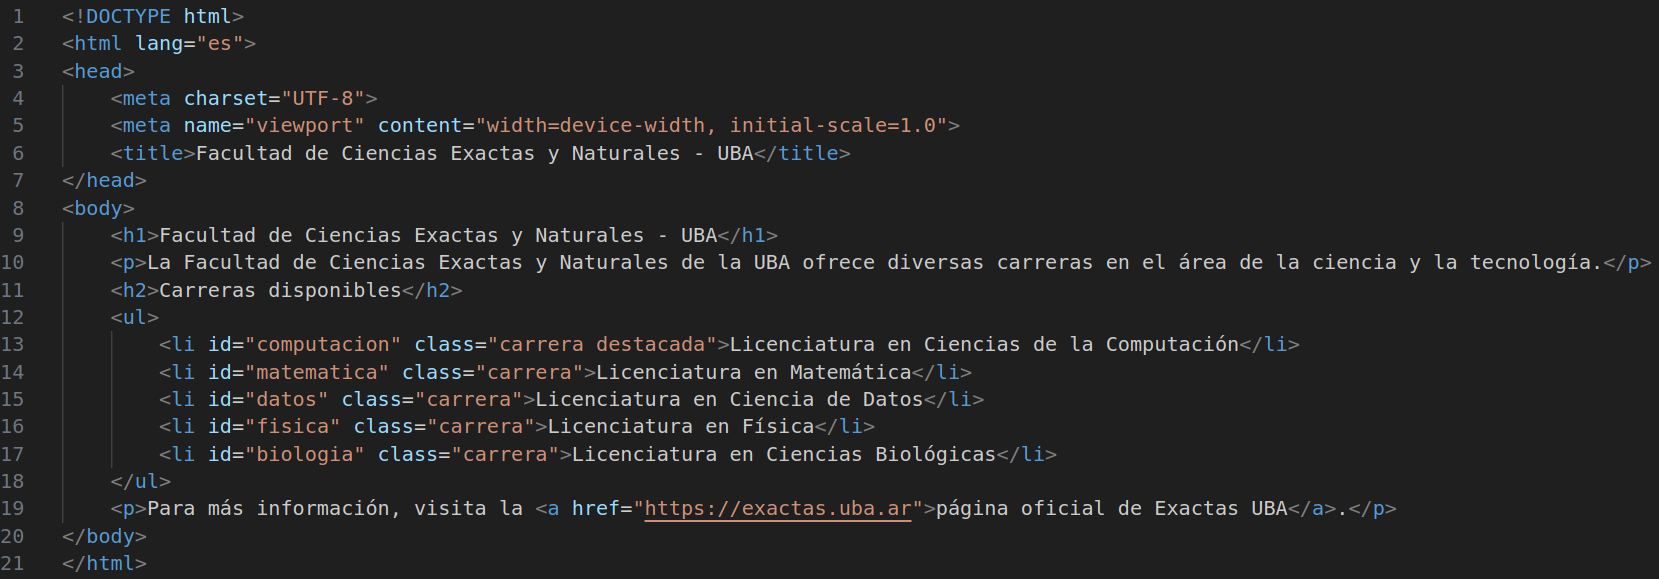

## Herramientas para extraer información

Para buscar elementos de HTML dentro de python contamos con las funciones find() y find_all(). La primera devuelve el primer elemento que cumple con las condiciones pedidas en los parámetros y la segunda devuelve una lista con todos los elementos encontrados. Cabe notar que los elementos obtenidos incluyen todos los hijos que tienen.

El primer parámetro (opcional) corresponde a una etiqueta de HTML.
Luego se le puede pasar un diccionario con los atributos que queremos que cumpla el elemento en cuestión.

Pero para encontrar algo primero tenemos que saber que estamos buscando. Para eso, hay que investigar la página de la que queremos extraer la información. Usando el comando f12 podemos acceder al código HTML de una página y ver como está estructurado. También se puede hacer click derecho en un elemento, seleccionar inspeccionar y se abre la misma pestaña pero centrada en ese elemento.

De ahí podemos obtener información relevante como los nombres de las clases, los id y la estructura de la página.

In [11]:
r = requests.get("https://lcd.exactas.uba.ar/materias/")
materias = BeautifulSoup(r.text, 'html.parser')
materias.find('h1')

<h1 class="entry-title">Plan de estudios</h1>

In [12]:
materias.find_all('h1')

[<h1 class="entry-title">Plan de estudios</h1>,
 <h1 class="title-heading-center" style="margin:0;color:#2981a2;"><b>Plan de <span style="color: #9bd279;">estudios</span></b></h1>]

Para acceder a los valores de los atributos podemos usar el comando .get()

In [13]:
materias.find('h1').get('class')

['entry-title']

In [14]:
print(materias.find('h1').get('style'))
print(materias.find('h2').get('style'))

None
color:#f9f9fb;


Podemos buscar elementos de la página buscando sus atributos como clase o estilo.

In [15]:
materias.find_all(attrs={'class':'flip-box-heading-back'})

materias.find_all('h3', attrs={'class':'flip-box-heading-back'})

[<h3 class="flip-box-heading-back" style="color:#ffffff;">Datos</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Investigación operativa y Optimización</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Estadística matemática-computacional</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Modelado continuo</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Sistemas estocásticos y complejos</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Inteligencia Artificial</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Procesamiento de Señales</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Cs. de la atmósfera</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Bioinformática</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Ciencias Sociales</h3>,
 <h3 class="flip-box-heading-back" style="color:#ffffff;">Ciencias Económicas</h3>]

In [16]:
materias.find_all('li', attrs={'style':True})

[<li style="font-weight: 400;"><span style="font-weight: 400;">Modelos de regresión</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Herramientas de visualización de datos</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Estimación no paramétrica aplicada</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Aprendizaje automático</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Procesamiento del lenguaje natural</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Introducción a las bases de datos</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Programación lineal entera avanzada</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Programación no lineal avanzada</span></li>,
 <li style="font-weight: 400;"><span style="font-weight: 400;">Optimización estocástica</span></li>,
 <li style="font-weight: 400;"><span

A veces, los elementos pueden tener varias clases. Se pueden acceder a esos elementos consultando por cualquiera de las clases.

In [17]:
div = materias.find(attrs={'class':'fusion-layout-column'})
div.get('class')

['fusion-layout-column',
 'fusion_builder_column',
 'fusion-builder-column-0',
 'fusion_builder_column_1_1',
 '1_1',
 'fusion-flex-column']

Podemos usar los comandos find() y find_all() en un elemento para buscar elementos que sean hijos del primero. Intentemos acceder a todas las filas de la tabla del cronograma sugerido a partir de algún elemento padre.

In [18]:
div = materias.find('ul')
div.find_all('li')

[<li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-home menu-item-2009" data-item-id="2009" id="menu-item-2009"><a class="fusion-textcolor-highlight" href="https://lcd.exactas.uba.ar/"><span class="menu-text">Inicio</span></a></li>,
 <li class="menu-item menu-item-type-custom menu-item-object-custom menu-item-has-children menu-item-2010 fusion-dropdown-menu" data-item-id="2010" id="menu-item-2010"><a class="fusion-textcolor-highlight" href="https://lcd.exactas.uba.ar/institucional/"><span class="menu-text">Institucional</span></a><ul class="sub-menu"><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-2011 fusion-dropdown-submenu" id="menu-item-2011"><a class="fusion-textcolor-highlight" href="https://lcd.exactas.uba.ar/institucional/"><span>Información General</span></a></li><li class="menu-item menu-item-type-post_type menu-item-object-page menu-item-2012 fusion-dropdown-submenu" id="menu-item-2012"><a class="fusion-textcolor-high

In [19]:
materias.find_all(attrs={'class':'fusion-column-wrapper fusion-content-layout-column'})
#divs.find_all(attrs={'class':'fusion-row'})

#materias.select('header.fusion-is-sticky')

[]

In [20]:
divs = materias.find_all(attrs={'class':'table'})
len(divs)

1

In [21]:
div = materias.find(attrs={'class':'table'})
rows = div.find_all('tr') #tr: table row
for row in rows:
  celdas = row.find_all('td')
  print(celdas)

[<td width="73"><strong>Cuatrimestre</strong></td>, <td width="194"><strong>Asignatura</strong></td>, <td width="131"><strong>Correlatividad de Asignaturas</strong></td>]
[<td width="73">3</td>, <td width="194">Álgebra I</td>, <td width="131">CBC</td>]
[<td width="73">3</td>, <td width="194">Algoritmos y Estructuras de Datos I</td>, <td width="131">CBC</td>]
[<td width="73">4</td>, <td width="194">Análisis I</td>, <td width="131">CBC</td>]
[<td width="73">4</td>, <td width="194">Algoritmos y Estructuras de Datos II</td>, <td width="131">Algoritmos y Estructuras de Datos I – Álgebra I</td>]
[<td width="73">5</td>, <td width="194">Análisis II</td>, <td width="131">Análisis I</td>]
[<td width="73">5</td>, <td width="194">Álgebra Lineal Computacional</td>, <td width="131">Álgebra I – Algoritmos y Estructuras de Datos II</td>]
[<td width="73">5</td>, <td width="194">Laboratorio de Datos</td>, <td width="131">Algoritmos y Estructuras de Datos I</td>]
[<td width="73">6</td>, <td width="194">A

In [22]:
div = materias.find(attrs={'class':'table'})
rows = div.find_all('tr') #tr: table row
for row in rows:
  celdas = row.find_all('td')
  print(celdas[0].text, celdas[1].text, celdas[2].text)

Cuatrimestre Asignatura Correlatividad de Asignaturas
3 Álgebra I CBC
3 Algoritmos y Estructuras de Datos I CBC
4 Análisis I CBC
4 Algoritmos y Estructuras de Datos II Algoritmos y Estructuras de Datos I – Álgebra I
5 Análisis II Análisis I
5 Álgebra Lineal Computacional Álgebra I – Algoritmos y Estructuras de Datos II
5 Laboratorio de Datos Algoritmos y Estructuras de Datos I
6 Análisis Avanzado Análisis II, Álgebra I
6 Electiva de Introducción a las Ciencias Naturales CBC
7 Probabilidad Análisis Avanzado
7 Algoritmos y Estructura de Datos III Algoritmos y Estructuras de Datos II
8 Intr. a la Estadística y Ciencia de Datos Lab de Datos, Probabilidad, Álgebra Lineal Computacional
8 Intr. a la Investigación Operativa y Optimización Alg y Estruc de Datos III, Análisis II, Álgebra Lineal Computacional
8 Intr. al Modelado Continuo. Análisis Avanzado, Álgebra Lineal Computacional


## Ejercicio

Armar un DataFrame que para cada uno de los cursos propuestos para el último ciclo, guarde todas las materias correspondientes al mismo.

In [23]:
import pandas as pd

In [24]:
Caminos = pd.DataFrame(columns=['Titulo', 'Materias'])

caminos = materias.find_all(attrs={'class':'fusion-flip-box-wrapper'})
for camino in caminos:
  titulo = camino.find('h3').text
  listado = camino.find_all('li')

  cursos = []
  for curso in listado:
    cursos.append(curso.text)

  Caminos.loc[len(Caminos)] = [titulo, cursos]
Caminos

,Titulo,Materias
0,Datos,"[Modelos de regresión, Herramientas de visuali..."
1,Investigación operativa y Optimización,"[Programación lineal entera avanzada, Programa..."
2,Estadística matemática-computacional,"[Modelo lineal, Herramientas de visualización ..."
3,Modelado continuo,"[Análisis numérico., Elementos de análisis fun..."
4,Sistemas estocásticos y complejos,"[Teoría de probabilidades., Modelos matemático..."
5,Inteligencia Artificial,"[Organización de Computadoras I, Aprendizaje A..."
6,Procesamiento de Señales,"[Frames, Descomposiciones atómicas y teoría de..."
7,Cs. de la atmósfera,"[Introducción a la dinámica de geofluidos, Int..."
8,Bioinformática,"[Introducción a la bioinformática molecular., ..."
9,Ciencias Sociales,"[Herramientas de visualización de datos, Análi..."


## Extraer Imagenes

In [25]:
materias.find_all(attrs={'src':True})

materias.find_all('img')

[<img alt="Licenciatura en Datos – Exactas – UBA Logo" class="fusion-standard-logo" data-retina_logo_url="https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo140.png" height="70" src="https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo289-2.png" srcset="https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo289-2.png 1x, https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo140.png 2x" style="max-height:70px;height:auto;" width="289"/>,
 <img alt="Licenciatura en Datos – Exactas – UBA Logo" class="fusion-sticky-logo" data-retina_logo_url="https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo140.png" height="70" src="https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo289-2.png" srcset="https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo289-2.png 1x, https://lcd.exactas.uba.ar/wp-content/uploads/2023/06/lic-datos-logo140.png 2x" style="max-height:70px;height:auto;" width="289"/>,


In [26]:
url_imagen = materias.find(attrs={'image_id':"2395"}).get('src')

imagen = requests.get(url_imagen)

with open("imagen.png", 'wb') as f:
  f.write(imagen.content)

## Expresiones Regulares

Una expresión regular (también son conocidas como regex) es una secuencia de caracteres que conforma un patrón de búsqueda. Se utilizan principalmente para la búsqueda de patrones de cadenas de caracteres u operaciones de sustituciones.

Para poder detectar estas expresiones regulares vamos a utilizar la libreria re de Python. Con ella podemos usar distintas expresiones como ^ para indicar como debe empezar la expresión o $ para indicar como debe terminar.

Se pueden consultar más formas de formar expresiones regulares en la [documentación](https://docs.python.org/3/library/re.html).

In [27]:
import re

In [28]:
elementos = materias.find_all(attrs={'class':re.compile('^flip-box')})
for e in elementos:
  print(e.get('class'))

['fusion-flip-boxes', 'flip-boxes', 'row', 'fusion-columns-3', 'flip-effect-classic', 'equal-heights', 'flip-tracks']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['

In [29]:
elementos = materias.find_all(attrs={'class':re.compile('heading$')})
for e in elementos:
  print(e.get('class'))

['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['panel-heading']
['fusion-toggle-heading']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-heading', 'without-text']
['flip-box-hea

In [30]:
elementos = materias.find_all(attrs={'class':re.compile('flip')})
for e in elementos:
  print(e.get('class'))

['fusion-flip-boxes', 'flip-boxes', 'row', 'fusion-columns-3', 'flip-effect-classic', 'equal-heights', 'flip-tracks']
['fusion-flip-box-wrapper', 'fusion-column', 'col-lg-4', 'col-md-4', 'col-sm-4']
['fusion-flip-box', 'flip-right']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['fusion-flip-box-wrapper', 'fusion-column', 'col-lg-4', 'col-md-4', 'col-sm-4']
['fusion-flip-box', 'flip-right']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['fusion-flip-box-wrapper', 'fusion-column', 'col-lg-4', 'col-md-4', 'col-sm-4']
['fusion-flip-box', 'flip-right']
['flip-box-inner-wrapper']
['flip-box-front']
['flip-box-front-inner']
['flip-box-heading', 'without-text']
['flip-box-back']
['flip-box-back-inner']
['flip-box-heading-back']
['fusion-

In [31]:
elementos = materias.find_all(attrs={'class':re.compile('^flip-box-back$')})
for e in elementos:
  print(e.get('class'))

['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']
['flip-box-back']


In [32]:
elementos = materias.find_all(attrs={'class':re.compile('^flip-box-(back|front)')})
for e in elementos:
  print(e.get('class'))

['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']
['flip-box-front']
['flip-box-front-inner']
['flip-box-back']
['flip-box-back-inner']


## Legalidad

El web scraping es una práctica legal, pero es necesario conocer las restricciones que pueden imponer los sitios web. Muchas páginas especifican en su archivo robots.txt qué partes de su dominio pueden o no ser scrapeadas. Este archivo, actúa como una guía para los bots y scrapers, indicando qué secciones del sitio pueden ser accedidas.

En sí, robots.txt es una sugerencia y su cumplimiento no es obligatorio, pero de todos modos es altamente recomendable respetarlo. Ignorarlo puede generar consecuencias como el bloqueo de nuestra IP.

Además, es recomendable revisar los términos y condiciones de cada página para conocer su política respecto a la extracción de datos. Algunas plataformas prohíben explícitamente el scraping en sus términos de uso, y no respetarlo podría derivar en acciones legales o sanciones.

El archivo robots.txt separa las restricciones para los distintos tipo de usuarios. Para esto, hace uso del comando User-agent. En caso de querer hacer referencia a todos los se indica con un asterisco.

Luego, se usan las palabras Disallow y Allow para indicar que secciones estan habilitadas para acceder.

Dos comandos comunes suelen ser 'Disallow: /' que indica que se bloquea la totalidad de las secciones; y 'Disallow: ' que indica que no se bloquea ninguna de las secciones.

In [33]:
url = "https://exactas.uba.ar/robots.txt"
r = requests.get(url)
robots_exactas = BeautifulSoup(r.text, 'html.parser')
robots_exactas

User-agent: *
Disallow: /calendar/action~posterboard/
Disallow: /calendar/action~agenda/
Disallow: /calendar/action~oneday/
Disallow: /calendar/action~month/
Disallow: /calendar/action~week/
Disallow: /calendar/action~stream/
Disallow: /calendar/action~undefined/
Disallow: /calendar/action~http:/
Disallow: /calendar/action~default/
Disallow: /calendar/action~poster/
Disallow: /calendar/action~*/
Disallow: /*controller=ai1ec_exporter_controller*
Disallow: /*/action~*/

In [34]:
url = "https://wikipedia.org/robots.txt"
r = requests.get(url)
robots_wikipedia = BeautifulSoup(r.text, 'html.parser')
robots_wikipedia

Please set a user-agent and respect our robot policy https://w.wiki/4wJS. See also T400119.

## Ejercicio

Hacer un listado de todos los nombres y precios de las publicaciones que aparecen en la primera página de busqueda de Mercado Libre para algún producto.

# APIs

Algunas páginas nos facilitan el acceso a la información a través de APIs (Application Programming Interface). Estas son interfaces que nos permiten interactuar con una página web o un sistema de manera estructurada y eficiente.

Las APIs funcionan como puentes de comunicación entre diferentes aplicaciones, permitiendo que un programa solicite y reciba datos sin necesidad de acceder directamente al código fuente del otro.

La información suele entregarse en formatos estandarizados como JSON (JavaScript Object Notation) o XML (eXtensible Markup Language), lo que facilita su procesamiento en distintos lenguajes de programación.

## Archivos .JSON

In [35]:
url_poke = "https://pokeapi.co/api/v2/pokemon/charizard"

r_poke = requests.get(url_poke)
r_poke.status_code

200

In [36]:
pokemon = r_poke.json()
pokemon.keys()

dict_keys(['abilities', 'base_experience', 'cries', 'forms', 'game_indices', 'height', 'held_items', 'id', 'is_default', 'location_area_encounters', 'moves', 'name', 'order', 'past_abilities', 'past_types', 'species', 'sprites', 'stats', 'types', 'weight'])

In [37]:
pokemon['types']

[{'slot': 1,
  'type': {'name': 'fire', 'url': 'https://pokeapi.co/api/v2/type/10/'}},
 {'slot': 2,
  'type': {'name': 'flying', 'url': 'https://pokeapi.co/api/v2/type/3/'}}]

In [38]:
pokemon['types'][0]['type']

{'name': 'fire', 'url': 'https://pokeapi.co/api/v2/type/10/'}

## Ejercicio

Comparar la relación de cambio de distintas monedas a partir de la api de CoinGecko ("https://api.coingecko.com/api/v3/exchange_rates")

In [39]:
url = "https://api.coingecko.com/api/v3/exchange_rates"
data = requests.get(url).json()
data

{'rates': {'btc': {'name': 'Bitcoin',
   'unit': 'BTC',
   'value': 1.0,
   'type': 'crypto'},
  'eth': {'name': 'Ether', 'unit': 'ETH', 'value': 30.279, 'type': 'crypto'},
  'ltc': {'name': 'Litecoin',
   'unit': 'LTC',
   'value': 984.597,
   'type': 'crypto'},
  'bch': {'name': 'Bitcoin Cash',
   'unit': 'BCH',
   'value': 188.314,
   'type': 'crypto'},
  'bnb': {'name': 'Binance Coin',
   'unit': 'BNB',
   'value': 102.128,
   'type': 'crypto'},
  'eos': {'name': 'EOS', 'unit': 'EOS', 'value': 398002.851, 'type': 'crypto'},
  'xrp': {'name': 'XRP', 'unit': 'XRP', 'value': 43273.371, 'type': 'crypto'},
  'xlm': {'name': 'Lumens',
   'unit': 'XLM',
   'value': 371458.347,
   'type': 'crypto'},
  'link': {'name': 'Chainlink',
   'unit': 'LINK',
   'value': 6759.604,
   'type': 'crypto'},
  'dot': {'name': 'Polkadot',
   'unit': 'DOT',
   'value': 33995.167,
   'type': 'crypto'},
  'yfi': {'name': 'Yearn.finance',
   'unit': 'YFI',
   'value': 20.998,
   'type': 'crypto'},
  'sol': {'n

In [40]:
data['rates']['ars']

{'name': 'Argentine Peso', 'unit': '$', 'value': 128366829.385, 'type': 'fiat'}

## API wrappers

Un API Wrapper es una librería o módulo que actúa como una capa de abstracción sobre una API. Su propósito es facilitar el acceso a la API sin que el usuario tenga que hacer llamadas HTTP manuales.

In [41]:
!pip install Wikipedia-API #==0.5.8 #Usamos esta version porque versiones más nuevas exigen indicar un user_agent

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for Wikipedia-API: filename=wikipedia_api-0.8.1-py3-none-any.whl size=15483 sha256=7bd0b7cff8cc6371888146e7ac87a9e9378fc6c3204a6606112e3fa1a2900cc0
  Stored in directory: /home/kenetc/.cache/pip/wheels/33/3c/79/b36253689d838af4a0539782853ac3cc38a83a6591ad570dde
Successfully built Wikipedia-API

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [42]:
!pip install Wikipedia-API
import wikipediaapi


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


https://foundation.wikimedia.org/wiki/Policy:Wikimedia_Foundation_User-Agent_Policy

In [43]:
wiki = wikipediaapi.Wikipedia(user_agent='Clase-APIs (mateogs01@gmail.com)', language='es')

In [44]:
arg = wiki.page('Argentina')

print(f"Título: {arg.title}")

print("\nResumen:\n")
print(arg.summary)

print("\nSecciones principales:")
for seccion in arg.sections:
    print(f"- {seccion.title}")

Título: Argentina

Resumen:

Argentina, oficialmente República Argentina,​ es un país soberano de América del Sur, ubicado en el extremo sur y sudeste de ese subcontinente. Adopta la forma de gobierno republicana, democrática, representativa y federal. Se constituye como un país federal descentralizado, compuesto por veintitrés provincias más la Ciudad Autónoma de Buenos Aires, designada como capital federal.​​
La Constitución Nacional Argentina rige los principios de adhesión entre 23 estados  asociados —denominadas provincias—, bajo una sola representación com Capital Federal en la Ciudad Autónoma de Buenos Aires. Dichas jurisdicciones gozan atributos plenos en los poderes ejecutivo, legislativo y judicial. Poseen ley suprema, bandera y fuerzas de seguridad propias, así como el dominio de recursos naturales circunscriptos. Las facultades en defensa, moneda, derechos y garantías, se delegan al gobierno nacional. Las extensas disputas tras la emancipación española en 1816 hasta consoli

## La foto del dia de la nasa

In [45]:
url = "https://api.nasa.gov/planetary/apod?api_key=DEMO_KEY"
data = requests.get(url).json()
print(f"Imagen del día: {data['title']} \n{data['url']}")

Imagen del día: Chamaeleon Dark Nebulas 
https://apod.nasa.gov/apod/image/2511/Chamaeleon_Houbo_960.jpg
